<a href="https://colab.research.google.com/github/ankit-kr6/LEARNING-ML/blob/main/video_43.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!kaggle datasets download -d yadavhim/placement-csv

Dataset URL: https://www.kaggle.com/datasets/yadavhim/placement-csv
License(s): CC0-1.0
100% 3.65k/3.65k [00:00<00:00, 9.05MB/s]



In [2]:
import zipfile

# Add the '.zip' extension so Python can actually find the file
with zipfile.ZipFile('placement-csv.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_csv('placement.csv')

In [5]:
df.sample(5)

,cgpa,placement_exam_marks,placed
340,7.45,51.0,0
409,6.92,24.0,0
160,7.36,10.0,1
98,8.12,76.0,0
80,6.87,46.0,1


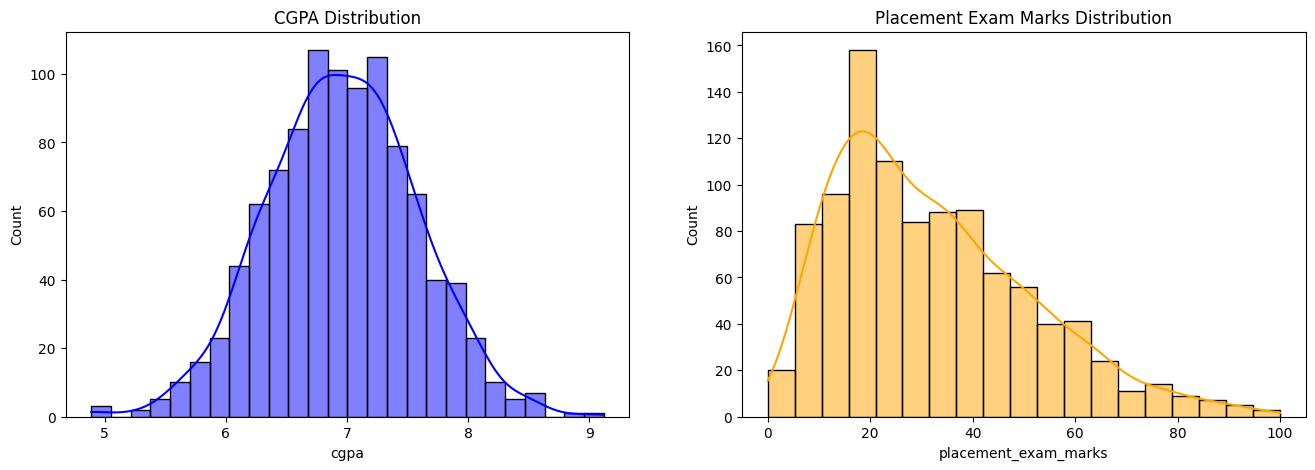

In [6]:
plt.figure(figsize=(16, 5))

# Left subplot: CGPA Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['cgpa'], kde=True, color='blue')
plt.title('CGPA Distribution')

# Right subplot: Placement Exam Marks Distribution
plt.subplot(1, 2, 2)
sns.histplot(df['placement_exam_marks'], kde=True, color='orange')
plt.title('Placement Exam Marks Distribution')

plt.show()

In [8]:
df['placement_exam_marks'].skew()

np.float64(0.8356419499466834)

In [9]:
df['placement_exam_marks'].describe()

,placement_exam_marks
count,1000.000000
mean,32.225000
std,19.130822
min,0.000000
25%,17.000000
50%,28.000000
75%,44.000000
max,100.000000


<Axes: ylabel='placement_exam_marks'>

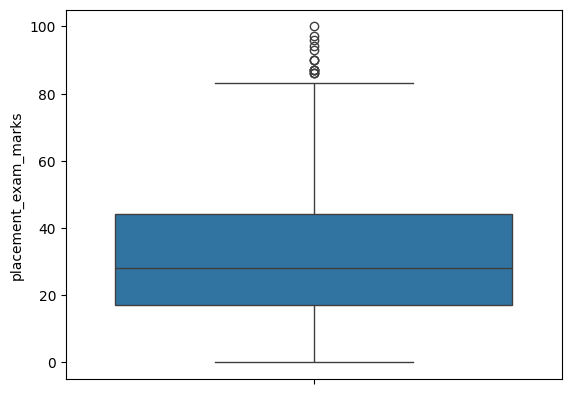

In [10]:
sns.boxplot(df['placement_exam_marks'])

In [11]:
#finding the IQR
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)
IQR = percentile75 - percentile25
print(IQR)

27.0


In [12]:
upper_limit=percentile75+1.5*IQR
lower_limit=percentile25-1.5*IQR
print(lower_limit)
print(upper_limit)

-23.5
84.5


In [13]:
#finding outliers
df[(df['placement_exam_marks']>upper_limit) ]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [15]:
df[(df['placement_exam_marks']<lower_limit) ]


,cgpa,placement_exam_marks,placed


In [18]:
#Trimming
new_df=df[(df['placement_exam_marks']<upper_limit) & (df['placement_exam_marks']>lower_limit) ]
new_df.shape

(985, 3)

In [21]:
#capping
new_df_cap=df.copy()
new_df_cap['placement_exam_marks']=np.where(
    new_df_cap['placement_exam_marks']>upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks']<lower_limit
        ,lower_limit,
        new_df_cap['placement_exam_marks']))


In [23]:
new_df_cap.shape

(1000, 3)